# 03 — Exploratory Data Analysis (EDA) & Visualization

## What we're looking for

Before building any predictive model, we need to understand the *shape* of
our sales data: how revenue moves over time, whether it's seasonal, which
products/customers/countries drive it, and whether anything looks unusual.

This matters directly for later steps:
- **Trends and seasonality** tell us what features a forecasting model needs
  (e.g. month-of-year, day-of-week, holiday proximity).
- **Concentration** (do a few customers/products dominate revenue?) tells us
  whether aggregate forecasting is stable or dominated by a few big players.
- **Outliers** found here get handled explicitly rather than silently
  confusing a model later.

We work from the **cleaned** dataset saved by Notebook 02 — never re-derive
cleaning logic here, just load the already-cleaned output.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

df = pd.read_csv('../data/processed/cleaned_retail.csv', parse_dates=['InvoiceDate'])
print(f"Rows: {len(df):,} | Date range: {df['InvoiceDate'].min().date()} to {df['InvoiceDate'].max().date()}")
df.head()

Matplotlib is building the font cache; this may take a moment.


Rows: 779,425 | Date range: 2009-12-01 to 2011-12-09


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,InvoiceNo,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,489434,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,489434,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,489434,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,489434,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,489434,30.0


## 1. Overall sales trend over time

We aggregate Revenue by day first (our finest useful grain for this dataset),
then resample to weekly/monthly to see the trend without daily noise.

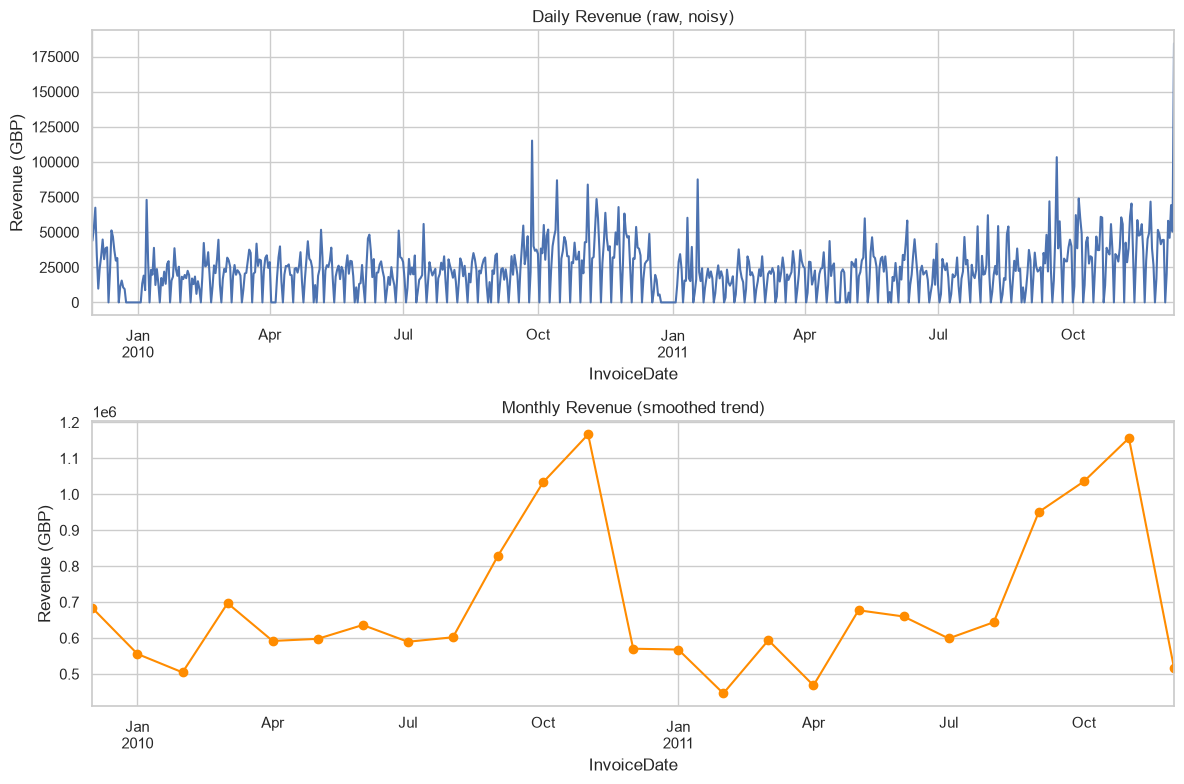

In [2]:
daily_revenue = df.set_index('InvoiceDate').resample('D')['Revenue'].sum()
monthly_revenue = daily_revenue.resample('ME').sum()

fig, axes = plt.subplots(2, 1, figsize=(12, 8))
daily_revenue.plot(ax=axes[0], title='Daily Revenue (raw, noisy)')
axes[0].set_ylabel('Revenue (GBP)')

monthly_revenue.plot(ax=axes[1], marker='o', title='Monthly Revenue (smoothed trend)', color='darkorange')
axes[1].set_ylabel('Revenue (GBP)')
plt.tight_layout()
plt.show()

**What to look for:** an overall upward/downward trend, and any sudden
spikes or drops that might be data issues rather than real business events
(e.g. a single huge wholesale order).

## 2. Seasonality — is there a repeating pattern?

We check two common retail seasonality signals:
- **Month of year** (e.g. a pre-Christmas surge in Nov/Dec — this company sells gift-ware)
- **Day of week** (weekday vs weekend buying patterns for wholesale buyers)

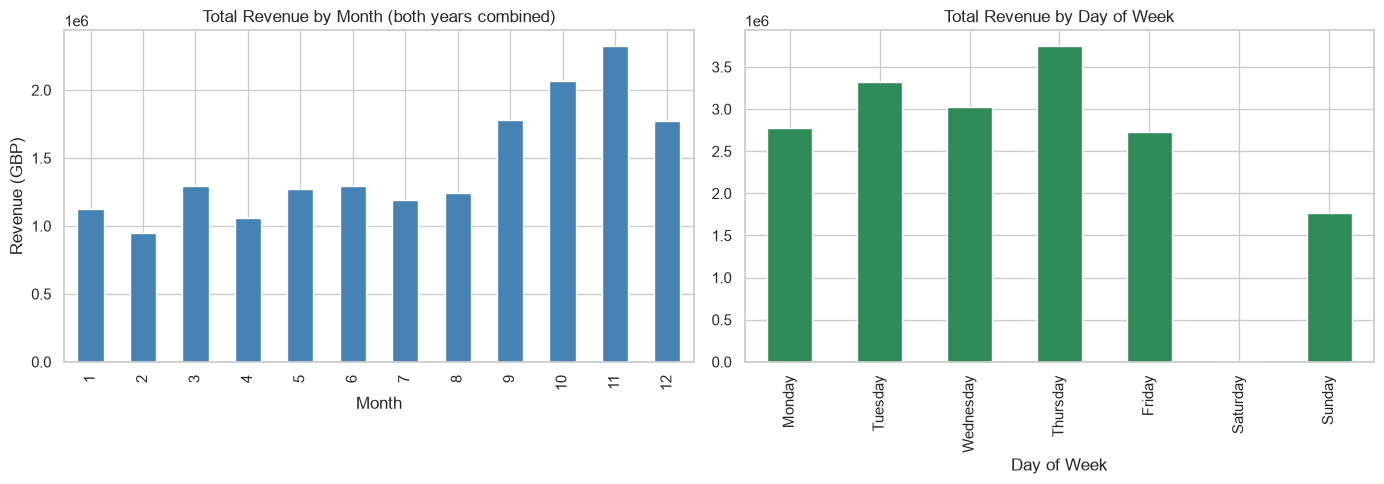

In [3]:
df['Month'] = df['InvoiceDate'].dt.month
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

monthly_avg = df.groupby('Month')['Revenue'].sum()
monthly_avg.plot(kind='bar', ax=axes[0], color='steelblue', title='Total Revenue by Month (both years combined)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Revenue (GBP)')

dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_avg = df.groupby('DayOfWeek')['Revenue'].sum().reindex(dow_order)
dow_avg.plot(kind='bar', ax=axes[1], color='seagreen', title='Total Revenue by Day of Week')
axes[1].set_xlabel('Day of Week')

plt.tight_layout()
plt.show()

**What to look for:** if certain months (Nov/Dec) or certain weekdays
consistently spike, that's a strong signal to build calendar-based features
(month, is-holiday-season, day-of-week) in Notebook 04. Note: this retailer
has almost no Saturday transactions historically — worth confirming, not
assuming a data bug.

## 3. Revenue concentration — top products, customers, countries

Real business data is rarely evenly distributed. We check for the classic
80/20 pattern: do a small number of products/customers/countries account
for most of the revenue?

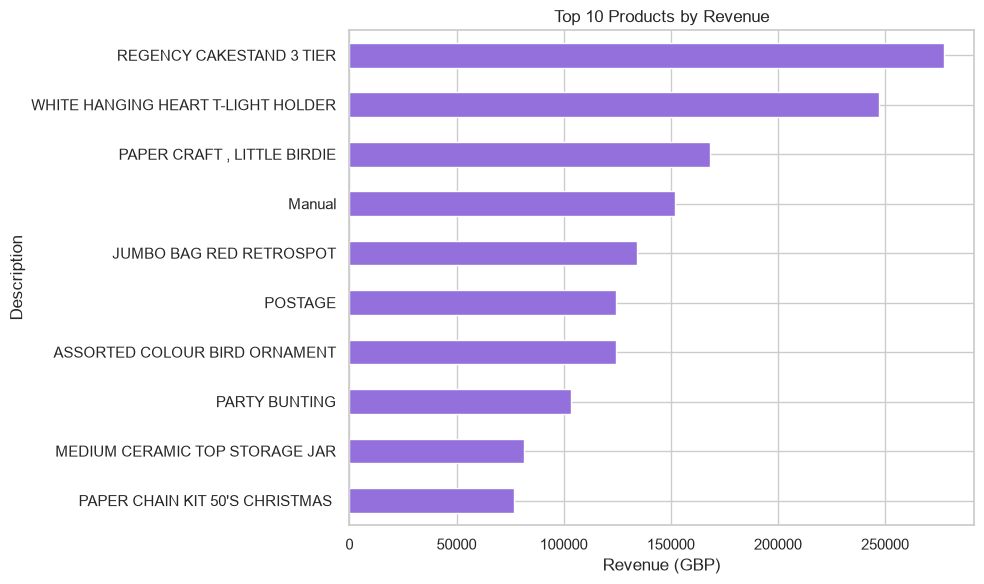

In [4]:
top_products = df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)
top_products.plot(kind='barh', figsize=(10, 6), color='mediumpurple', title='Top 10 Products by Revenue')
plt.xlabel('Revenue (GBP)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

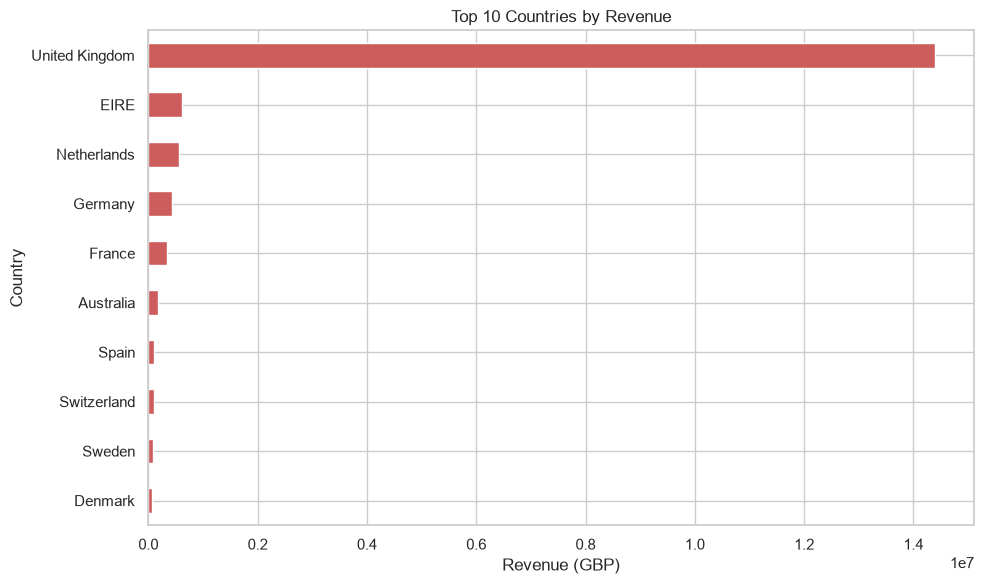

Top country (United Kingdom) accounts for 82.8% of total revenue.


In [5]:
top_countries = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
top_countries.plot(kind='barh', figsize=(10, 6), color='indianred', title='Top 10 Countries by Revenue')
plt.xlabel('Revenue (GBP)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

uk_share = top_countries.iloc[0] / df['Revenue'].sum() * 100
print(f"Top country ({top_countries.index[0]}) accounts for {uk_share:.1f}% of total revenue.")

Total unique customers: 5,878
Top 20% of customers generate 77.2% of total revenue.


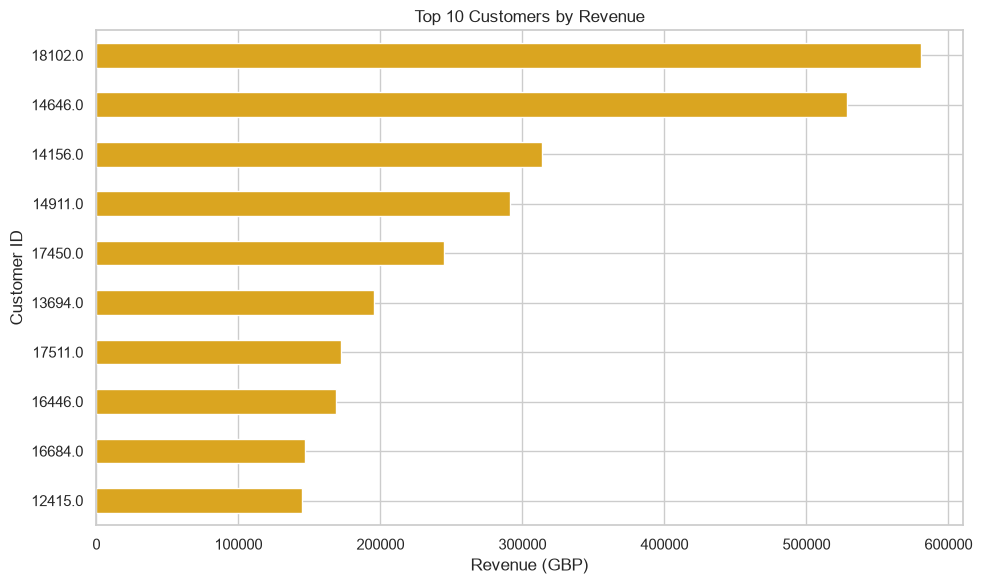

In [6]:
customer_revenue = df.groupby('Customer ID')['Revenue'].sum().sort_values(ascending=False)
top_20pct_cutoff = int(len(customer_revenue) * 0.2)
revenue_from_top_20pct = customer_revenue.iloc[:top_20pct_cutoff].sum() / customer_revenue.sum() * 100

print(f"Total unique customers: {len(customer_revenue):,}")
print(f"Top 20% of customers generate {revenue_from_top_20pct:.1f}% of total revenue.")

customer_revenue.head(10).plot(kind='barh', figsize=(10, 6), color='goldenrod', title='Top 10 Customers by Revenue')
plt.xlabel('Revenue (GBP)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

**Why this matters for forecasting:** if revenue is heavily concentrated in
one country or a handful of customers, a single large/lost account can swing
our aggregate forecast independent of any real trend. This tells us whether
to consider segmenting the forecast (e.g. UK vs rest-of-world) later.

## 4. Order value distribution — are there extreme outliers?

We look at revenue per invoice line to check for extreme values that might
distort aggregate statistics or need special handling before modeling.

count    779425.000000
mean         22.291823
std         227.427075
min           0.001000
25%           4.950000
50%          12.480000
75%          19.800000
max      168469.600000
Name: Revenue, dtype: float64


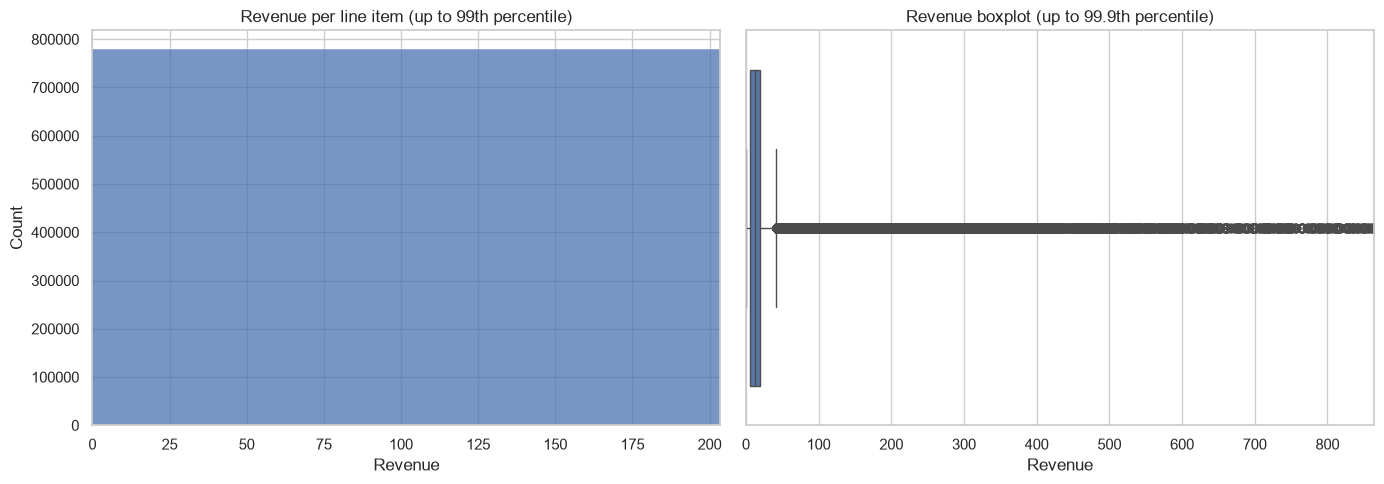


99th percentile revenue per line: 203.52
Max revenue per line: 168469.60


In [7]:
print(df['Revenue'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Revenue'], bins=100, ax=axes[0])
axes[0].set_xlim(0, df['Revenue'].quantile(0.99))  # zoom past the extreme tail
axes[0].set_title('Revenue per line item (up to 99th percentile)')

sns.boxplot(x=df['Revenue'], ax=axes[1])
axes[1].set_xlim(0, df['Revenue'].quantile(0.999))
axes[1].set_title('Revenue boxplot (up to 99.9th percentile)')
plt.tight_layout()
plt.show()

print(f"\n99th percentile revenue per line: {df['Revenue'].quantile(0.99):.2f}")
print(f"Max revenue per line: {df['Revenue'].max():.2f}")

**Why this matters:** a heavy right tail (a handful of huge wholesale line
items) is expected in this dataset since the company sells partly to
wholesalers. We're *noting* this, not removing it — these are legitimate
sales, not data errors (we already removed real errors in Notebook 02).
Aggregating to daily/weekly totals before modeling (Notebook 05) naturally
smooths this out.

## Summary of findings

_Fill this in after running the cells above:_
- Is there a clear upward/downward trend in monthly revenue?
- Which months are strongest (does it match a Nov/Dec gift-buying pattern)?
- How concentrated is revenue by country/customer?
- Are there extreme outliers we should be aware of during modeling?

These observations directly inform **Notebook 04 — Feature Engineering**,
where we turn these patterns (seasonality, trend, customer behavior) into
actual model inputs (lag features, rolling averages, calendar features).